In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTAMOS LIBRERIAS DE SKLEARN

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# CARGAMOS EL DATASET

In [49]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data',header=None,sep='\s+')
df.columns =  ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


# EDA

In [50]:
df.isna().sum().sum()

0

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## CORRELACIONES

<Axes: >

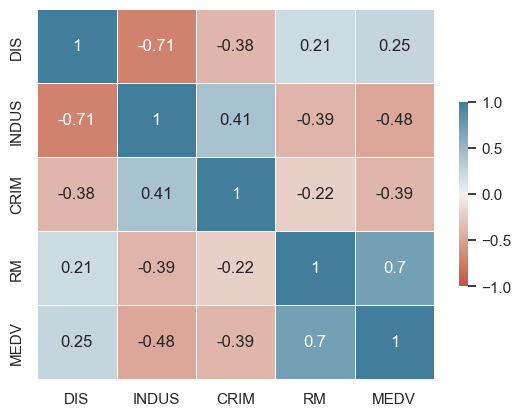

In [52]:
cols = ['DIS','INDUS','CRIM', 'RM', 'MEDV']
sns.heatmap(
    data=df[cols].corr(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [53]:
import plotly.express as px
cols = ['DIS','INDUS','CRIM', 'RM', 'MEDV']
data=df[cols]
fig = px.scatter_matrix(data,
    title="Scatter matrix ")
fig.show()

C:\Users\ingma\anaconda3\lib\site-packages\plotly\express\_core.py:279: FutureWarning:

iteritems is deprecated and will be removed in a future version. Use .items instead.



<Axes: xlabel='RM', ylabel='MEDV'>

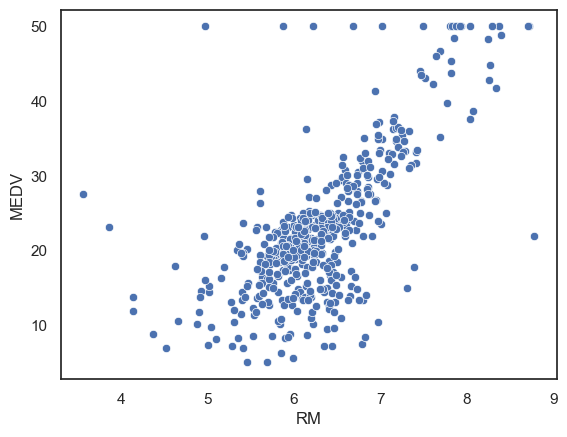

In [54]:
sns.scatterplot(data=df,x=df['RM'],y=df['MEDV'])

<Axes: xlabel='DIS', ylabel='INDUS'>

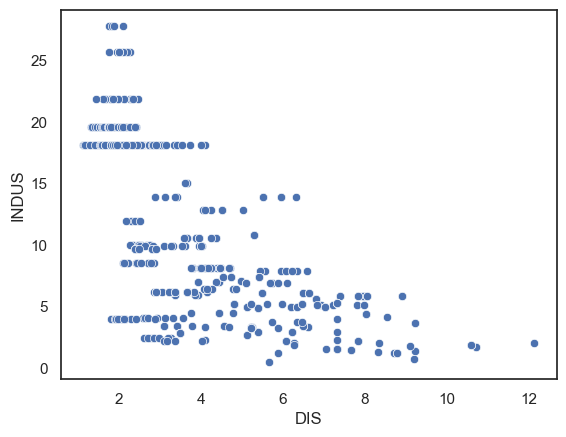

In [55]:
sns.scatterplot(data=df,x=df['DIS'],y=df['INDUS'])

# CREANDO EL MODULO DE REGRESIÓN LINEAL CON SKLEARN
## X = RM(Promedio de habitaciones en el departamento)
## Y = MEDV(Valor promedio del departamento)

In [56]:
X = df['RM'].values.reshape(-1,1)
y = df['MEDV'].values.reshape(-1,1)

# ESTANDARIZAMOS LOS VALORES

In [58]:
sc_x = StandardScaler()
sc_y = StandardScaler()

X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y)


# CREAMOS EL MODELO DE REGRESIÓN LINEAL

In [74]:
slr = LinearRegression()
slr.fit(X_std,y_std)
slr.predict(X_std)
slr.score(X, y)
slr.coef_
slr.intercept_

array([-4.43892061e-16])

# GRAFICAMOS LOS RESULTADOS

Text(0.5, 0, 'RM')

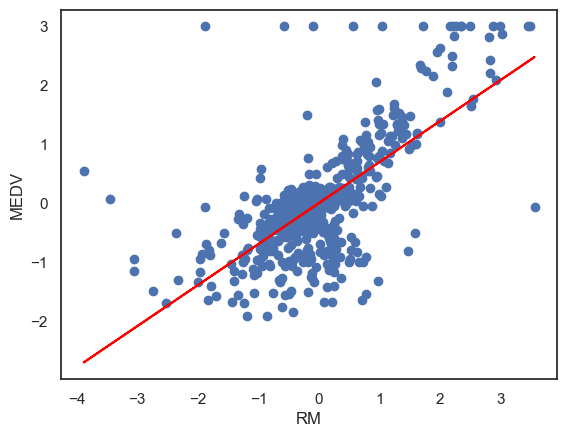

In [75]:
plt.scatter(X_std,y_std)
plt.plot(X_std,slr.predict(X_std),color='red')
plt.ylabel('MEDV')
plt.xlabel('RM')

# PROBAMOS PREDICCIONES

In [76]:
num_hab = 6.575
num_hab_std = sc_x.transform(np.array([num_hab]).reshape(-1,1))
print(f" EL PRECIO PARA UN DPTO CON {num_hab}  ES DE : {sc_y.inverse_transform(slr.predict(num_hab_std))}")

 EL PRECIO PARA UN DPTO CON 6.575  ES DE : [[25.17574577]]


# ENTRENAMOS NUESTRO MODELO DIVIENDO EL DATASET

In [96]:
from sklearn.model_selection import train_test_split

data = df.copy()
data.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.9,9.14,21.6


In [97]:
X = data['RM'].values.reshape(-1,1)
y = data['MEDV'].values.reshape(-1,1)

In [105]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20, random_state=42)

In [106]:
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.fit_transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.fit_transform(y_test)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_pred.shape

(102, 1)

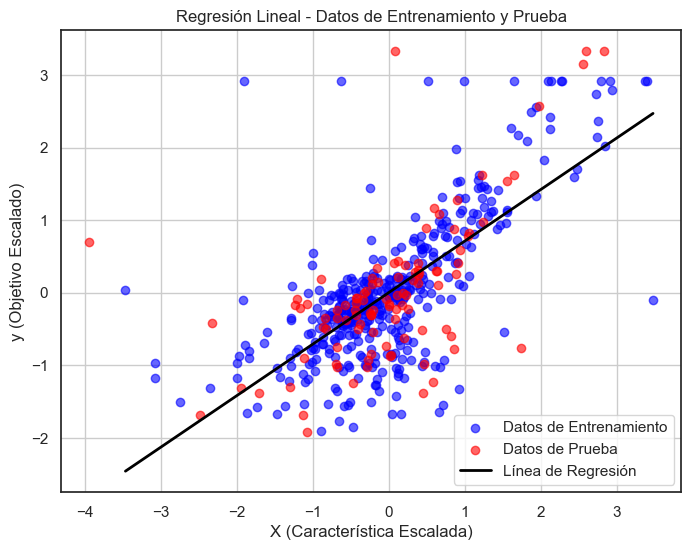

In [107]:
# Graficar datos de entrenamiento y prueba junto con la regresión
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='blue', label="Datos de Entrenamiento", alpha=0.6)
# Datos de prueba
plt.scatter(X_test, y_test, color='red', label="Datos de Prueba", alpha=0.6)           
# Línea de regresión
X_range = np.linspace(min(X_train), max(X_train), 100).reshape(-1, 1)
y_range_pred = model.predict(X_range)
plt.plot(X_range, y_range_pred, color='black', linewidth=2, label="Línea de Regresión")

plt.xlabel("X (Característica Escalada)")
plt.ylabel("y (Objetivo Escalado)")
plt.title("Regresión Lineal - Datos de Entrenamiento y Prueba")
plt.legend()
plt.grid(True)
plt.show()          

# METRICAS DEL MODELO

In [108]:
import sklearn.metrics as metrics

#erro cuadratico medio
mse = metrics.mean_squared_error(y_test,y_pred)
#R2 Coeficiente de determinación
r2 = metrics.r2_score(y_test,y_pred)

print(f'El error cuadratico medio(MSE) es de {round(mse,4)}')
print(f'El coeficiente de determinación(R2) es de {round(r2,4)}')


El error cuadratico medio(MSE) es de 0.6269
El coeficiente de determinación(R2) es de 0.3731
